<a href="https://colab.research.google.com/github/akshita2736/hypothyroid_project/blob/main/thyroid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Predictive Modeling Framework for Early Identification of Hypothyroidism among Women**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df = pd.read_csv('thyroidDF.csv')
df.head()

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,target,patient_id
0,29,F,f,f,f,f,f,f,f,t,...,NaN,f,NaN,f,NaN,f,NaN,other,-,840801013
1,29,F,f,f,f,f,f,f,f,f,...,128.0,f,NaN,f,NaN,f,NaN,other,-,840801014
2,41,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,11.0,other,-,840801042
3,36,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,26.0,other,-,840803046
4,32,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,36.0,other,S,840803047


In [ ]:
df.columns

Index(['age', 'sex', 'on_thyroxine', 'query_on_thyroxine',
       'on_antithyroid_meds', 'sick', 'pregnant', 'thyroid_surgery',
       'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium',
       'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH_measured', 'TSH',
       'T3_measured', 'T3', 'TT4_measured', 'TT4', 'T4U_measured', 'T4U',
       'FTI_measured', 'FTI', 'TBG_measured', 'TBG', 'referral_source',
       'target', 'patient_id'],
      dtype='object')

In [ ]:
pd.set_option('display.max_columns', None)
# to display all columns everytime

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9172 entries, 0 to 9171
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  9172 non-null   int64  
 1   sex                  8865 non-null   object 
 2   on_thyroxine         9172 non-null   object 
 3   query_on_thyroxine   9172 non-null   object 
 4   on_antithyroid_meds  9172 non-null   object 
 5   sick                 9172 non-null   object 
 6   pregnant             9172 non-null   object 
 7   thyroid_surgery      9172 non-null   object 
 8   I131_treatment       9172 non-null   object 
 9   query_hypothyroid    9172 non-null   object 
 10  query_hyperthyroid   9172 non-null   object 
 11  lithium              9172 non-null   object 
 12  goitre               9172 non-null   object 
 13  tumor                9172 non-null   object 
 14  hypopituitary        9172 non-null   object 
 15  psych                9172 non-null   o

In [ ]:
df.describe()

,age,TSH,T3,TT4,T4U,FTI,TBG,patient_id
count,9172.000000,8330.000000,6568.000000,8730.000000,8363.000000,8370.000000,349.000000,9.172000e+03
mean,73.555822,5.218403,1.970629,108.700305,0.976056,113.640746,29.870057,8.529473e+08
std,1183.976718,24.184006,0.887579,37.522670,0.200360,41.551650,21.080504,7.581969e+06
min,1.000000,0.005000,0.050000,2.000000,0.170000,1.400000,0.100000,8.408010e+08
25%,37.000000,0.460000,1.500000,87.000000,0.860000,93.000000,21.000000,8.504090e+08
50%,55.000000,1.400000,1.900000,104.000000,0.960000,109.000000,26.000000,8.510040e+08
75%,68.000000,2.700000,2.300000,126.000000,1.065000,128.000000,31.000000,8.607110e+08
max,65526.000000,530.000000,18.000000,600.000000,2.330000,881.000000,200.000000,8.701190e+08


In [ ]:
df.isnull().sum()

,0
age,0
sex,307
on_thyroxine,0
query_on_thyroxine,0
on_antithyroid_meds,0
sick,0
pregnant,0
thyroid_surgery,0
I131_treatment,0
query_hypothyroid,0


In [ ]:
# filtering out the data for only females
df_female = df[df['sex'] == 'F']
df_female.sample(5)

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH_measured,TSH,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,target,patient_id
2433,67,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,f,NaN,f,NaN,f,NaN,f,NaN,f,NaN,t,24.0,other,-,850418057
8143,56,F,f,t,f,f,f,f,f,f,f,f,f,f,f,f,t,1.600000,t,3.0,t,104.0,t,1.15,t,90.0,f,NaN,other,-,861016037
8872,61,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,9.099999,f,NaN,t,82.0,t,0.84,t,98.0,f,NaN,SVI,G,861215047
3005,70,F,f,f,f,f,f,f,f,f,t,f,f,t,f,f,t,0.005000,t,3.5,t,194.0,t,0.90,t,215.0,f,NaN,other,A,850531044
1466,63,F,f,f,f,t,f,f,f,f,f,f,f,f,f,f,t,4.700000,t,0.4,t,38.0,t,0.64,t,60.0,f,NaN,SVI,-,841130065


In [ ]:
df_female['sex'].value_counts()                  # 6073 instances

,count
sex,
F,6073


In [ ]:
# dropping irrelevant features
drop_cols = ['sex', 'TSH_measured', 'TT4_measured', 'T3_measured', 'FTI_measured', 'T4U_measured', 'TBG_measured', 'patient_id']
df_female = df_female.drop(drop_cols, axis=1)
df_female.head()

,age,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,TBG,referral_source,target
0,29,f,f,f,f,f,f,f,t,f,f,f,f,f,f,0.3,NaN,NaN,NaN,NaN,NaN,other,-
1,29,f,f,f,f,f,f,f,f,f,f,f,f,f,f,1.6,1.9,128.0,NaN,NaN,NaN,other,-
2,41,f,f,f,f,f,f,f,f,t,f,f,f,f,f,NaN,NaN,NaN,NaN,NaN,11.0,other,-
3,36,f,f,f,f,f,f,f,f,f,f,f,f,f,f,NaN,NaN,NaN,NaN,NaN,26.0,other,-
4,32,f,f,f,f,f,f,f,f,f,f,f,f,f,f,NaN,NaN,NaN,NaN,NaN,36.0,other,S


In [ ]:
# sorting patients by their age
df_female = df_female.sort_values(by='age')
df_female.tail()

,age,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,TBG,referral_source,target
5758,95,f,f,f,f,f,f,f,f,f,f,f,f,f,f,0.96,0.8,103.0,0.89,116.0,NaN,SVI,K
7355,97,f,f,f,f,f,f,f,f,f,f,f,f,f,f,2.90,0.5,101.0,0.64,158.0,NaN,SVI,-
790,97,f,f,f,f,f,f,f,f,f,f,f,f,f,f,3.20,1.3,84.0,0.97,87.0,NaN,SVI,-
2976,455,f,f,f,f,f,f,f,f,f,f,f,f,f,f,1.10,2.0,118.0,1.13,104.0,NaN,SVI,-
8105,65526,f,f,f,f,f,f,f,f,f,f,f,f,f,f,1.50,NaN,132.0,1.02,129.0,NaN,other,-


we can see that the last two patients have ages 455 and 65526 --- delete last 2 instances

In [ ]:
df_female = df_female.drop(df_female.tail(2).index, axis=0)       # removed last 2 rows (outliers)
# OR
# df_female = df_female.iloc[:-2]          # selects all rows except the last 2

df_female.tail(5)

,age,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,TBG,referral_source,target
9054,94,f,f,f,f,f,f,f,f,f,f,f,f,f,f,0.99,0.9,109.0,0.92,119.0,NaN,SVI,K
8968,95,f,f,f,f,f,f,f,f,f,f,f,f,f,f,1.60,NaN,98.0,0.91,108.0,NaN,other,-
5758,95,f,f,f,f,f,f,f,f,f,f,f,f,f,f,0.96,0.8,103.0,0.89,116.0,NaN,SVI,K
7355,97,f,f,f,f,f,f,f,f,f,f,f,f,f,f,2.90,0.5,101.0,0.64,158.0,NaN,SVI,-
790,97,f,f,f,f,f,f,f,f,f,f,f,f,f,f,3.20,1.3,84.0,0.97,87.0,NaN,SVI,-


Now we have to sort the data for only hypothyroid categories:

'-' : Negative

'F' : Primary Hypothyroid

'G' : Compensated Hypothyroid

In [ ]:
df_hypo = df_female[df_female['target'].isin(['-','F','G'])]
df_hypo.head(12)

,age,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,TBG,referral_source,target
1267,1,f,f,f,f,f,f,f,f,f,f,f,f,f,f,0.800,1.6,110.0,0.77,143.0,NaN,SVI,-
8096,1,f,f,f,f,f,f,f,f,f,f,f,f,f,f,2.100,NaN,117.0,0.97,121.0,NaN,other,-
8504,2,t,f,f,f,f,f,f,t,f,f,f,f,f,f,4.100,NaN,155.0,1.04,149.0,NaN,STMW,-
3160,2,f,f,f,f,f,f,f,f,f,f,f,f,f,f,6.700,NaN,NaN,NaN,NaN,NaN,STMW,F
8254,2,f,f,f,f,f,f,f,t,f,f,f,f,f,f,136.000,NaN,53.0,0.77,69.0,NaN,STMW,-
4594,2,t,f,f,f,f,f,f,f,f,f,f,f,f,f,0.025,NaN,145.0,0.93,155.0,NaN,other,-
6980,3,f,f,f,f,f,f,f,f,f,f,f,f,f,f,NaN,3.9,NaN,NaN,NaN,NaN,STMW,-
8729,5,t,f,f,f,f,f,f,f,f,f,f,f,f,f,0.020,NaN,206.0,1.41,146.0,NaN,other,-
4773,6,f,f,f,f,f,f,f,f,f,f,f,f,f,f,1.400,2.0,134.0,0.96,140.0,NaN,SVI,-
1461,6,f,f,f,f,f,f,f,f,f,f,f,f,f,f,3.200,1.9,78.0,0.86,91.0,NaN,SVI,-


In [ ]:
df_hypo.shape             # no. of instances of hypothyroidism in females = 4768

(4768, 23)

In [ ]:
df_hypo.isnull().sum()

,0
age,0
on_thyroxine,0
query_on_thyroxine,0
on_antithyroid_meds,0
sick,0
pregnant,0
thyroid_surgery,0
I131_treatment,0
query_hypothyroid,0
query_hyperthyroid,0


In [ ]:
# number of missing values in TBG column are quite high (4577) --- drop the column
df_hypo = df_hypo.drop('TBG', axis=1)
df_hypo.head()

,age,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,referral_source,target
1267,1,f,f,f,f,f,f,f,f,f,f,f,f,f,f,0.8,1.6,110.0,0.77,143.0,SVI,-
8096,1,f,f,f,f,f,f,f,f,f,f,f,f,f,f,2.1,NaN,117.0,0.97,121.0,other,-
8504,2,t,f,f,f,f,f,f,t,f,f,f,f,f,f,4.1,NaN,155.0,1.04,149.0,STMW,-
3160,2,f,f,f,f,f,f,f,f,f,f,f,f,f,f,6.7,NaN,NaN,NaN,NaN,STMW,F
8254,2,f,f,f,f,f,f,f,t,f,f,f,f,f,f,136.0,NaN,53.0,0.77,69.0,STMW,-


In [ ]:
df_hypo.columns

Index(['age', 'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_meds',
       'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment',
       'query_hypothyroid', 'query_hyperthyroid', 'lithium', 'goitre', 'tumor',
       'hypopituitary', 'psych', 'TSH', 'T3', 'TT4', 'T4U', 'FTI',
       'referral_source', 'target'],
      dtype='object')

In [ ]:
df_hypo['target'].value_counts()
# highly imbalanced data

,count
target,
-,4331
G,263
F,174


UNIVARIATE ANALYSIS OF NUMERICAL COLUMNS

In [ ]:
# List of hormone columns to check
hormone_cols = ['TSH', 'T3', 'TT4', 'T4U', 'FTI']

# Count rows where ALL hormone values are missing (NaN)
missing_all = df_hypo[hormone_cols].isnull().all(axis=1).sum()
print(f"Number of instances with all hormone values missing: {missing_all}")

Number of instances with all hormone values missing: 179


In [ ]:
# Drop rows where ALL of these values are missing
df_hypo = df_hypo.dropna(subset=hormone_cols, how='all')

missing_all_new = df_hypo[hormone_cols].isnull().all(axis=1).sum()
print(f"Number of instances with all hormone values missing: {missing_all_new}")

Number of instances with all hormone values missing: 0


Creating histograms for numerical columns to check if the data is skewed or normally distributed

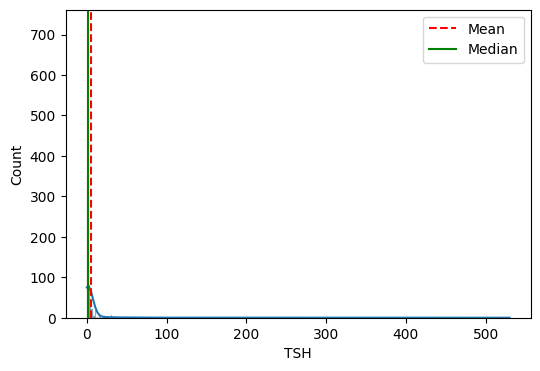

Mean result of TSH is:  5.218402753781513
Median result: TSH is:  1.4




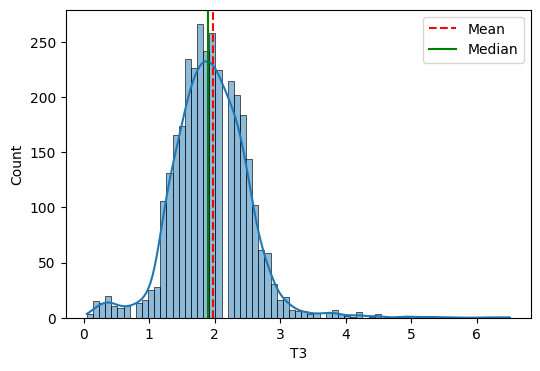

Mean result of T3 is:  1.970628805724726
Median result: T3 is:  1.9




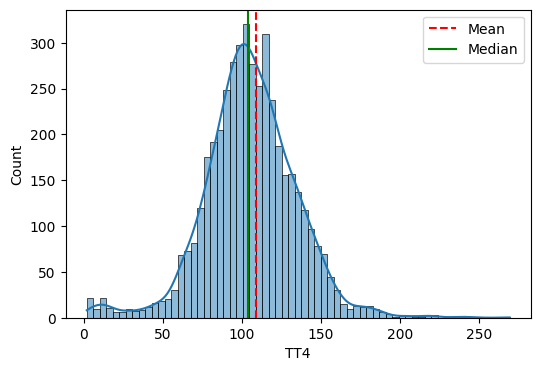

Mean result of TT4 is:  108.70030469644902
Median result: TT4 is:  104.0




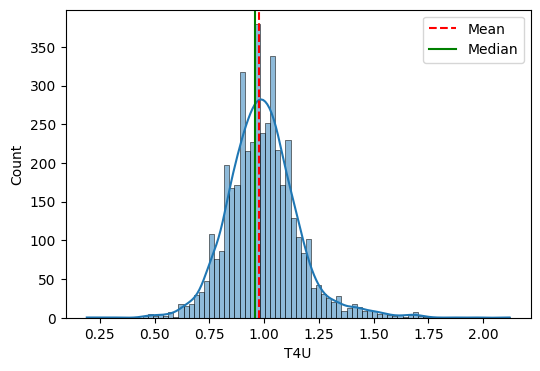

Mean result of T4U is:  0.9760557216309935
Median result: T4U is:  0.96




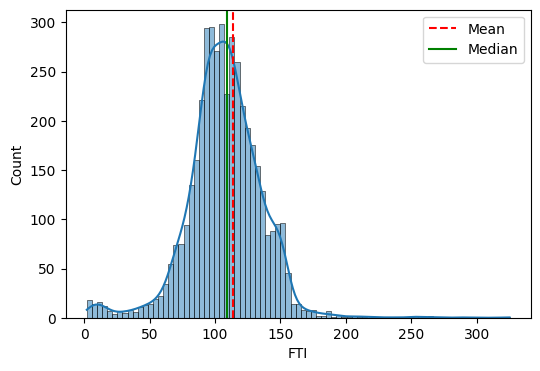

Mean result of FTI is:  113.64074551935484
Median result: FTI is:  109.0




In [ ]:
for col in ['TSH', 'T3', 'TT4', 'T4U', 'FTI']:
  plt.figure(figsize=(6,4))
  sns.histplot(df_hypo[col], kde=True)

  mean_result = df[col].mean()
  median_result = df[col].median()
  # Draw vertical lines for mean and median on the plot
  plt.axvline(mean_result, color="red", linestyle="--", label="Mean")
  plt.axvline(median_result, color="green", linestyle="-", label="Median")

  plt.legend()
  plt.show()
  # Print values
  print("Mean result of", col, "is: ", mean_result)
  print("Median result:", col, "is: ", median_result)
  print("\n")

from the histograms we see that:

TSH is highly skewed -- many outliers in data -- missing values should be replaced with MEDIAN

T3, TT4, T4U, FTI -- normal distribution -- replace missing values with MEAN

In [ ]:
df_hypo['TSH'].fillna(df_hypo['TSH'].median(), inplace=True)

for col in ['T3', 'TT4', 'T4U', 'FTI']:
  df_hypo[col].fillna(df_hypo[col].mean(), inplace=True)

/tmp/ipython-input-317826178.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_hypo['TSH'].fillna(df_hypo['TSH'].median(), inplace=True)
/tmp/ipython-input-317826178.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

In [ ]:
df_hypo.isnull().sum()

,0
age,0
on_thyroxine,0
query_on_thyroxine,0
on_antithyroid_meds,0
sick,0
pregnant,0
thyroid_surgery,0
I131_treatment,0
query_hypothyroid,0
query_hyperthyroid,0


Now, all the missing values have been handled.

In [ ]:
df_hypo.tail(5)

,age,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,referral_source,target
8297,93,f,f,f,f,f,f,f,f,f,f,f,f,f,f,0.98,1.9351,88.0,0.66,133.0,SVI,-
5238,94,f,f,f,f,f,f,f,f,f,f,f,f,f,f,3.90,1.9351,157.0,1.02,154.0,SVI,-
8968,95,f,f,f,f,f,f,f,f,f,f,f,f,f,f,1.60,1.9351,98.0,0.91,108.0,other,-
7355,97,f,f,f,f,f,f,f,f,f,f,f,f,f,f,2.90,0.5000,101.0,0.64,158.0,SVI,-
790,97,f,f,f,f,f,f,f,f,f,f,f,f,f,f,3.20,1.3000,84.0,0.97,87.0,SVI,-


In [ ]:
df_hypo.shape

(4589, 22)

In [ ]:
# Sample 500 instances from '-' class
df_negative_sample = df_hypo[df_hypo['target'] == '-'].sample(n=500, random_state=42)

# Select all instances of 'F' and 'G'
df_hypo_fg = df_hypo[df_hypo['target'].isin(['F', 'G'])]

# Concatenate them together
df_balanced = pd.concat([df_negative_sample, df_hypo_fg], axis=0).reset_index(drop=True)

# Shuffle the dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Check class distribution
print(df_balanced['target'].value_counts())

target
-    500
G    263
F    174
Name: count, dtype: int64


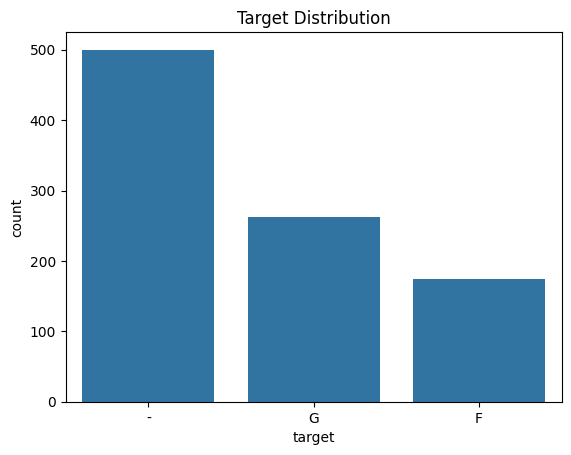

In [ ]:
plt.plot(figsize=(5,8))
sns.countplot(x='target', data=df_balanced)
plt.title("Target Distribution")
plt.show()

Checking outliers in numerical columns using BOXPLOT and IQR method

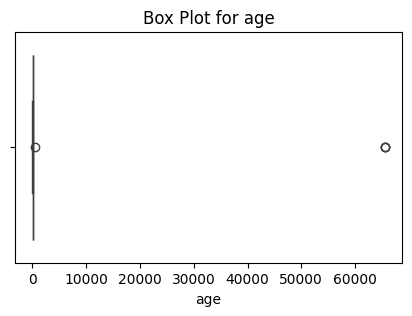

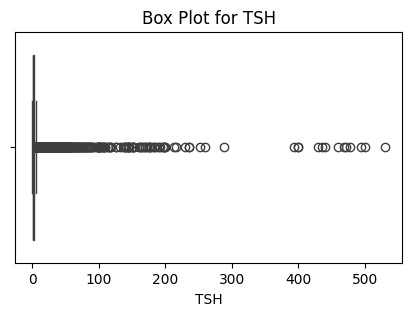

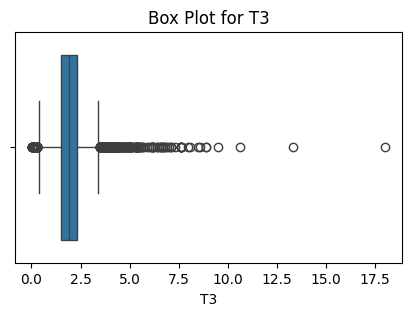

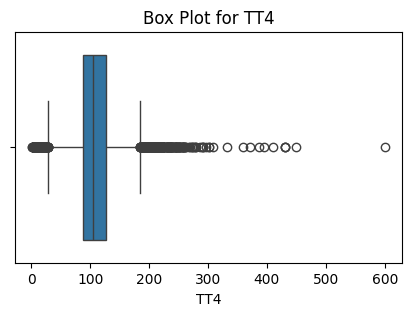

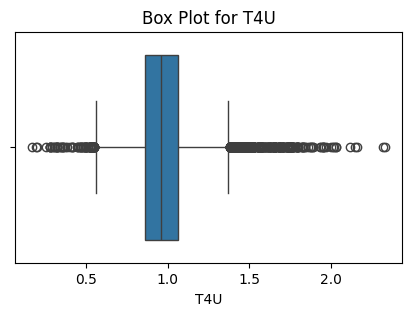

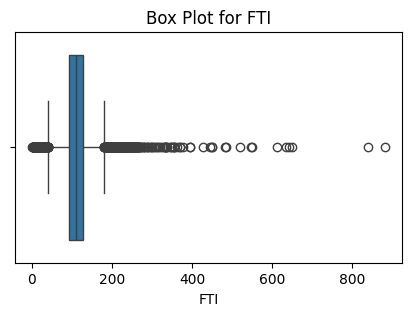

In [ ]:
for col in ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI']:
  plt.figure(figsize=(5,3))
  sns.boxplot(x=df[col])
  plt.title(f"Box Plot for {col}")
  plt.xlabel(col)
  plt.show()
  print("\n")

In [ ]:
df_balanced['target'].value_counts()
# will apply SMOTE for balancing the data (on the trained dataset)

,count
target,
-,500
G,263
F,174


count outliers using IQR method

In [ ]:
for col in ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI']:
  Q1 = df_balanced[col].quantile(0.25)
  Q3 = df_balanced[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = df_balanced[(df_balanced[col] < lower_bound) | (df_balanced[col] > upper_bound)]
  print(f"no. of outliers in {col} is: ", len(outliers), "\n")

no. of outliers in age is:  0 

no. of outliers in TSH is:  138 

no. of outliers in T3 is:  121 

no. of outliers in TT4 is:  40 

no. of outliers in T4U is:  33 

no. of outliers in FTI is:  68 



In [ ]:
# handling outliers -- replacing with median
cols_to_replace = ['TSH', 'T3', 'FTI']    # sensitive, more outliers
cols_to_leave = ['TT4', 'T4U', 'age']     # fewer or no outliers

for col in cols_to_replace:
    Q1 = df_balanced[col].quantile(0.25)
    Q3 = df_balanced[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    median = df_balanced[col].median()
    df_balanced.loc[(df_balanced[col] < lower) | (df_balanced[col] > upper), col] = median

In [ ]:
df_balanced.columns

Index(['age', 'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_meds',
       'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment',
       'query_hypothyroid', 'query_hyperthyroid', 'lithium', 'goitre', 'tumor',
       'hypopituitary', 'psych', 'TSH', 'T3', 'TT4', 'T4U', 'FTI',
       'referral_source', 'target'],
      dtype='object')

Encoding categorical columns to numerical columns

In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [ ]:
# applying label encoder on binary columns
binary_col = ['on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_meds',
       'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment',
       'query_hypothyroid', 'query_hyperthyroid', 'lithium', 'goitre', 'tumor',
       'hypopituitary', 'psych']
for col in binary_col:
  df_balanced[col] = df_balanced[col].map({'f':0, 't':1})

le = LabelEncoder()
df_balanced['target'] = le.fit_transform(df_balanced['target'])

In [ ]:
# applying one hot encoder on non-ordinal categorical columns
df_balanced = pd.get_dummies(df_balanced, columns=['referral_source'], drop_first=True)
# change False/True to 0/1
df_balanced = df_balanced.astype(int)

In [ ]:
df_balanced.sample(20)

,age,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,target,referral_source_SVHC,referral_source_SVHD,referral_source_SVI,referral_source_other
210,27,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,160,1,143,0,0,0,0,1
622,56,0,0,0,0,0,0,0,0,0,0,0,0,0,0,27,1,74,1,74,2,0,0,0,1
399,24,0,0,0,0,0,0,0,1,0,0,0,0,0,0,11,1,92,0,110,2,0,0,0,1
136,28,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,2,131,0,147,0,0,0,0,1
779,62,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,66,0,93,0,0,0,0,1
909,27,1,0,0,0,0,0,0,0,0,0,0,0,0,0,8,1,60,1,48,0,0,0,0,1
517,25,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,1,73,0,76,0,0,1,0,0
905,78,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,122,1,114,0,0,0,0,1
178,31,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,176,1,123,0,0,0,0,1
192,48,1,0,0,0,0,0,0,0,0,0,0,0,0,0,6,1,161,1,99,0,0,0,0,1


Correlation of each feature with the target (to avoid multicollinearity, spot redundancies/irrelevant factors)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

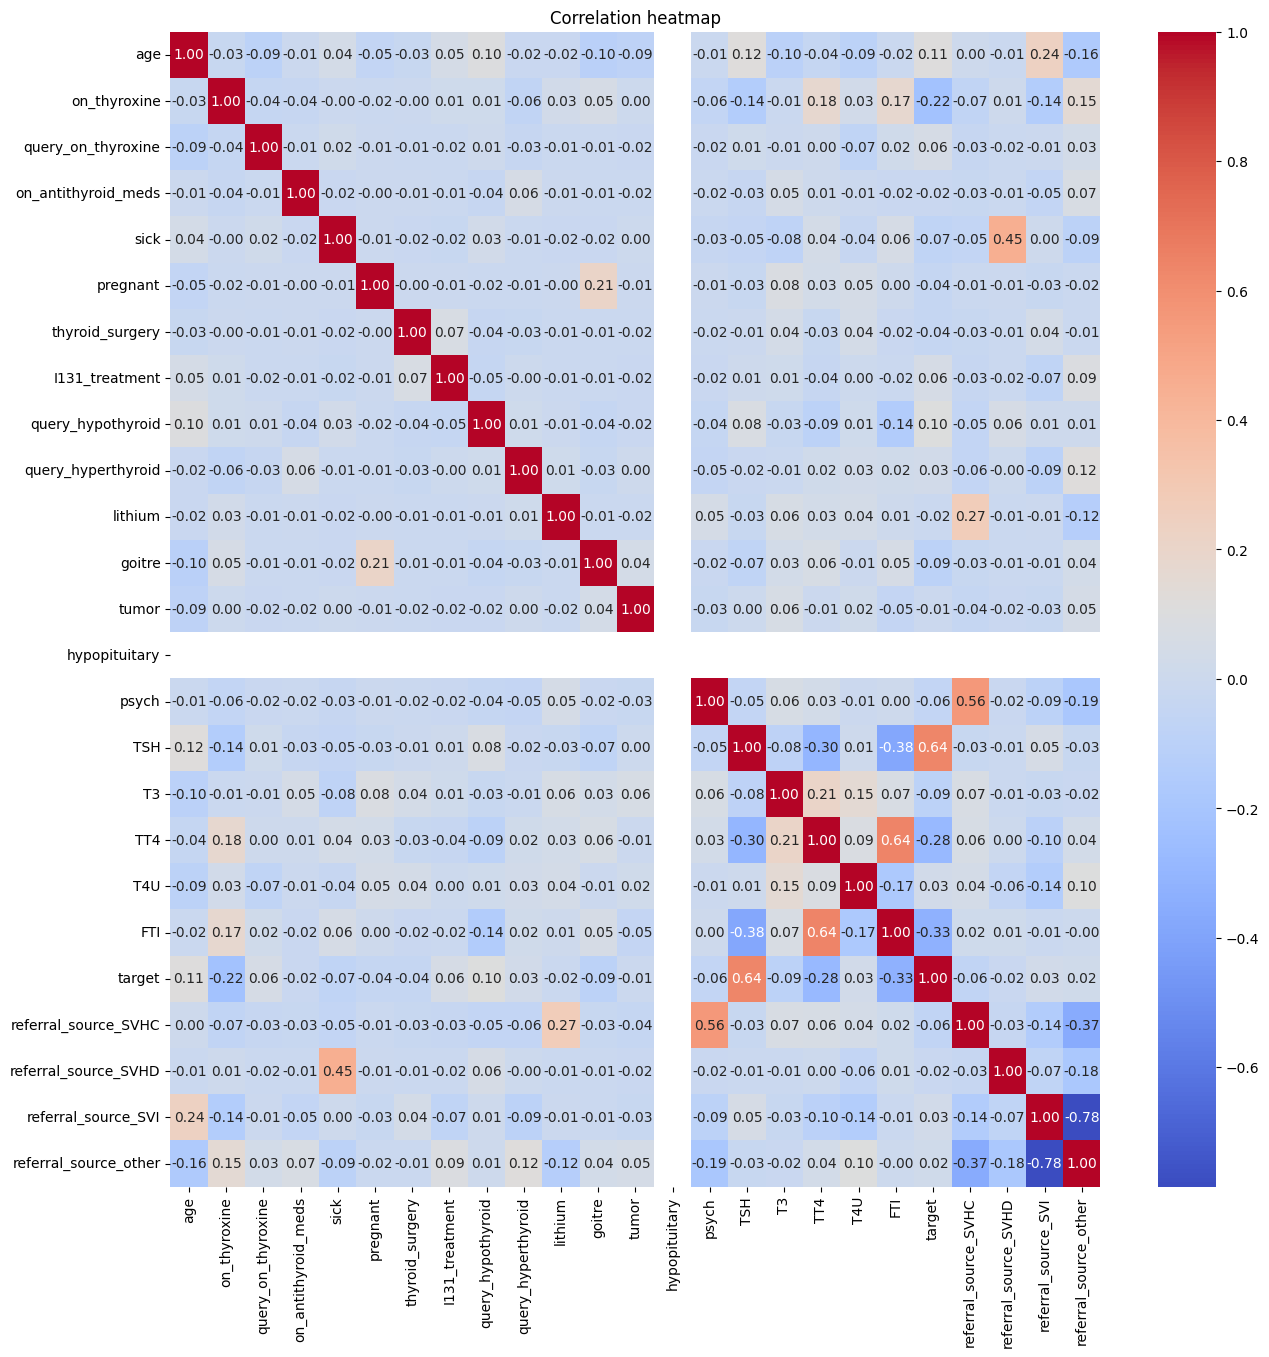

In [ ]:
# correlation matrix
plt.figure(figsize=(15, 15))
sns.heatmap(df_balanced.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap")
plt.show()
#df.corr():Calculates the correlation matrix for all numeric columns in your dataset.
#Tells how strongly each column is related to the others.

Show correlation with target only

In [ ]:
df_corr = df_balanced.corr(numeric_only=True)
corr_target = df_corr[['target']].sort_values(by='target', ascending=False)

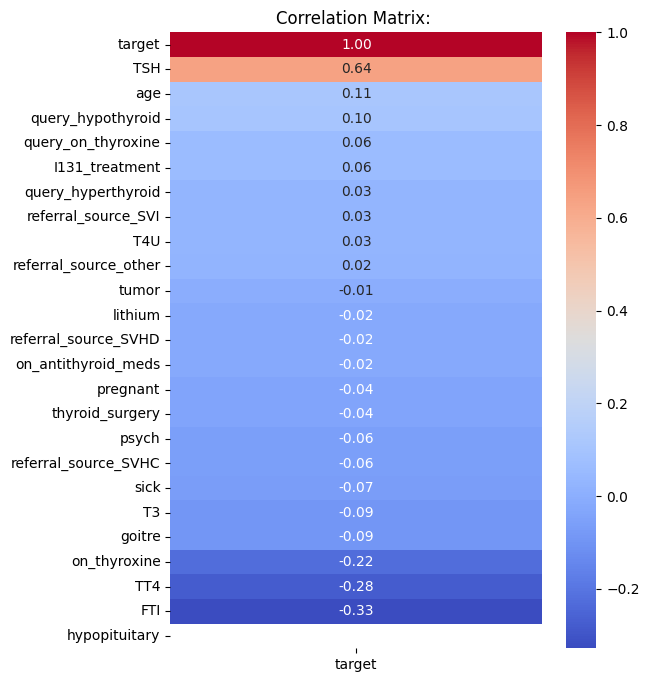

In [ ]:
plt.figure(figsize=(6,8))
sns.heatmap(corr_target, cmap='coolwarm', annot=True, fmt='.2f')
plt.title("Correlation Matrix: ")
plt.show()

Splitting the dataset into train and test data -- 80% train and 20% test

In [ ]:
x = df_balanced.drop('target', axis=1)
y = df_balanced['target']

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, random_state=42, test_size=0.2, stratify=y
)

Now applying SMOTE on train data -- to avoid class imbalance

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
smote = SMOTE(random_state=42)
x_train_res, y_train_res = smote.fit_resample(x_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print()
print("After SMOTE:\n", y_train_res.value_counts())

Before SMOTE:
 target
0    400
2    210
1    139
Name: count, dtype: int64

After SMOTE:
 target
1    400
2    400
0    400
Name: count, dtype: int64


Scaling (normalizing) only the numerical features

In [ ]:
x.columns

Index(['age', 'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_meds',
       'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment',
       'query_hypothyroid', 'query_hyperthyroid', 'lithium', 'goitre', 'tumor',
       'hypopituitary', 'psych', 'TSH', 'T3', 'TT4', 'T4U', 'FTI',
       'referral_source_SVHC', 'referral_source_SVHD', 'referral_source_SVI',
       'referral_source_other'],
      dtype='object')

In [ ]:
num_cols = ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI']

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_res[num_cols] = scaler.fit_transform(x_train_res[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

In [ ]:
x_train_res.head()

,age,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,referral_source_SVHC,referral_source_SVHD,referral_source_SVI,referral_source_other
0,0.776875,0,0,0,0,0,0,0,0,1,0,0,0,0,0,-0.360399,-0.439139,-1.512843,1.098127,0.253249,0,0,1,0
1,-0.161613,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.654438,-0.439139,-1.890142,-0.910642,0.253249,0,0,0,1
2,1.328927,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3.257405,-0.439139,-1.537997,1.098127,0.253249,0,0,1,0
3,0.445644,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0.242569,-0.439139,0.197579,-0.910642,0.363383,0,0,0,1
4,0.445644,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-0.812624,-0.439139,1.279169,1.098127,0.950769,1,0,0,0


In [ ]:
x_test.head()

,age,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,referral_source_SVHC,referral_source_SVHD,referral_source_SVI,referral_source_other
658,0.224823,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-0.812624,2.277184,1.027637,1.098127,0.583653,0,0,1,0
613,1.439337,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.242569,-0.439139,0.927024,-0.910642,1.574865,0,0,1,0
110,0.390439,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-0.360399,-0.439139,-1.839836,1.098127,0.253249,0,0,0,1
336,-1.155307,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-0.360399,-0.439139,-1.588303,1.098127,0.253249,0,0,0,1
379,-1.486538,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.297762,-0.439139,0.096966,-0.910642,0.326672,0,0,1,0


In [ ]:
y_train_res.value_counts()

,count
target,
1,400
2,400
0,400


In [ ]:
y_test.value_counts()

,count
target,
0,100
2,53
1,35


Now applying the models on the train dataset and calculating its confusion metrics:

**1) LOGISTIC REGRESSION**

In [ ]:
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(max_iter = 1000)
model_lr.fit(x_train_res, y_train_res)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred_lr = model_lr.predict(x_test)             # 1D array

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
print("Accuracy: ", accuracy_score(y_test, y_pred_lr))
print("\nconfusion_matrix: ", confusion_matrix(y_test, y_pred_lr))
print("\nclassification_report: ", classification_report(y_test, y_pred_lr))

Accuracy:  0.9361702127659575

confusion_matrix:  [[94  2  4]
 [ 1 31  3]
 [ 2  0 51]]

classification_report:                precision    recall  f1-score   support

           0       0.97      0.94      0.95       100
           1       0.94      0.89      0.91        35
           2       0.88      0.96      0.92        53

    accuracy                           0.94       188
   macro avg       0.93      0.93      0.93       188
weighted avg       0.94      0.94      0.94       188



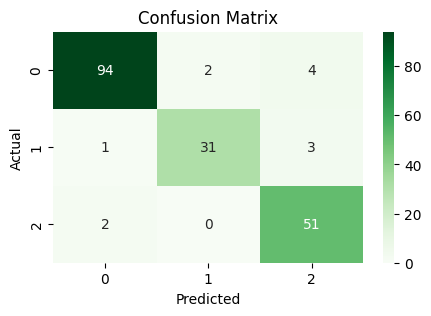

In [ ]:
cm = confusion_matrix(y_test, y_pred_lr, labels=model_lr.classes_)
plt.figure(figsize=(5,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=model_lr.classes_,
            yticklabels=model_lr.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Macro average - treats all classes equally
precision_macro = precision_score(y_test, y_pred_lr, average='macro')
recall_macro = recall_score(y_test, y_pred_lr, average='macro')
f1_macro = f1_score(y_test, y_pred_lr, average='macro')

print("For Logistic Regression: ")
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1:", f1_macro)

For Logistic Regression: 
Macro Precision: 0.9292588163899932
Macro Recall: 0.9293261455525607
Macro F1: 0.9283327818711515


achieved a 93.6% accuracy using logistic regression

**2) SUPPORT VECTOR MACHINE**

In [ ]:
from sklearn.svm import SVC
svm_model = SVC()

In [ ]:
param_grid_svm = [
    {'kernel': ['linear'],
     'C': [0.01, 0.1, 1, 10, 100]},
    {'kernel': ['rbf'],
     'C': [0.01, 0.1, 1, 10, 100],
     'gamma': ['scale', 'auto', 0.1, 0.01, 0.001]},
    {'kernel': ['poly'],
     'C': [0.01, 0.1, 1, 10],
     'degree': [2, 3, 4, 5],
     'gamma': ['scale', 'auto', 0.1, 0.01]}
]

In [ ]:
# HYPERPARAMETER TUNING
from sklearn.model_selection import GridSearchCV

In [ ]:
grid_search_svm = GridSearchCV(svm_model, param_grid_svm, cv=5, scoring='accuracy')
grid_search_svm.fit(x_train_res, y_train_res)

# to find best combination of hyperparameters using cross validation
# (C, kernel, gamma)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid=[{'C': [0.01, 0.1, 1, 10, 100], 'kernel': ['linear']},
                         {'C': [0.01, 0.1, 1, 10, 100],
                          'gamma': ['scale', 'auto', 0.1, 0.01, 0.001],
                          'kernel': ['rbf']},
                         {'C': [0.01, 0.1, 1, 10], 'degree': [2, 3, 4, 5],
                          'gamma': ['scale', 'auto', 0.1, 0.01],
                          'kernel': ['poly']}],
             scoring='accuracy')

In [ ]:
print("best hyperparameters for SVM: ", grid_search_svm.best_params_)

best hyperparameters for SVM:  {'C': 1, 'kernel': 'linear'}


In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
# cross validation accuracy of best model
cv_scores_svm = cross_val_score(grid_search_svm.best_estimator_, x_train_res, y_train_res, cv=5)
print("cross validation accuracy score: ", cv_scores_svm)
print("\nmean CV accuracy: ", np.mean(cv_scores_svm))

cross validation accuracy score:  [0.95833333 0.94583333 0.97083333 0.97916667 0.97083333]

mean CV accuracy:  0.9650000000000001


In [ ]:
# evaluate on test data
best_model_svm = grid_search_svm.best_estimator_
y_pred_svm = best_model_svm.predict(x_test)

In [ ]:
test_acc = accuracy_score(y_test, y_pred_svm)
print("Test accuracy of SVM:", test_acc)

Test accuracy of SVM: 0.9361702127659575


In [ ]:
cm = confusion_matrix(y_test, y_pred_svm)
print("confusion_matrix: \n", cm)

confusion_matrix: 
 [[95  2  3]
 [ 1 31  3]
 [ 2  1 50]]


In [ ]:
print("classification report of SVM: \n", classification_report(y_test, y_pred_svm))

classification report of SVM: 
               precision    recall  f1-score   support

           0       0.97      0.95      0.96       100
           1       0.91      0.89      0.90        35
           2       0.89      0.94      0.92        53

    accuracy                           0.94       188
   macro avg       0.92      0.93      0.93       188
weighted avg       0.94      0.94      0.94       188



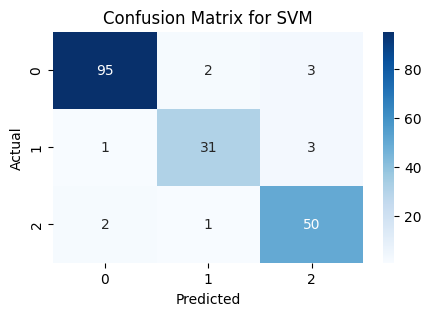

In [ ]:
cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(5,3))

# Class labels
labels = np.unique(y_test)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels,
            yticklabels=labels)
plt.title("Confusion Matrix for SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
precision_macro = precision_score(y_test, y_pred_svm, average='macro')
recall_macro = recall_score(y_test, y_pred_svm, average='macro')
f1_macro = f1_score(y_test, y_pred_svm, average='macro')

print("For SVM: ")
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1:", f1_macro)

For SVM: 
Macro Precision: 0.9246698679471789
Macro Recall: 0.9263701707097933
Macro F1: 0.925192625631397


Got an accuracy of 93.6% using SVM

**3) RANDOM** **FOREST**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)

In [ ]:
# Hyperparameter tuning
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],   # number of trees
    'max_depth': [None, 5, 10, 15, 20, 30],      # tree depth
    'min_samples_split': [2, 5, 10],             # min samples to split a node
    'min_samples_leaf': [1, 2, 4],               # min samples at a leaf node
    'max_features': ['sqrt', 'log2', None],      # number of features per split
    'bootstrap': [True, False]                   # bootstrap samples
}


In [ ]:
# Randomized search for faster tuning
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,                # number of random combos to try
    cv=5,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1,
    random_state=42
)
#  n_jobs = -1: use all available CPU cores to speed up the computation (parallel processing)

In [ ]:
rf_random.fit(x_train_res, y_train_res)
print("Best parameters:", rf_random.best_params_)
print("\nBest CV Accuracy:", rf_random.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}

Best CV Accuracy: 0.9824999999999999


In [ ]:
# Evaluate on test set
best_rf = rf_random.best_estimator_
y_pred_rf = best_rf.predict(x_test)

print("\nTest Accuracy of Random Forest:", accuracy_score(y_test, y_pred_rf))


Test Accuracy of Random Forest: 0.9680851063829787


In [ ]:
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.96      0.97       100
           1       0.92      0.97      0.94        35
           2       0.96      0.98      0.97        53

    accuracy                           0.97       188
   macro avg       0.96      0.97      0.96       188
weighted avg       0.97      0.97      0.97       188



In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
print("confusion_matrix: \n", cm)

confusion_matrix: 
 [[96  3  1]
 [ 0 34  1]
 [ 1  0 52]]


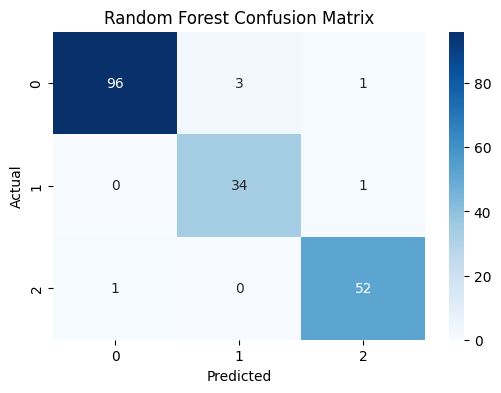

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_rf.classes_, yticklabels=best_rf.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Macro average → treats all classes equally
precision_macro = precision_score(y_test, y_pred_rf, average='macro')
recall_macro = recall_score(y_test, y_pred_rf, average='macro')
f1_macro = f1_score(y_test, y_pred_rf, average='macro')

print("For Random Forest Classifier: ")
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1:", f1_macro)

For Random Forest Classifier: 
Macro Precision: 0.9571908678437887
Macro Recall: 0.9708535489667565
Macro F1: 0.9636754502023254


Got an accuracy of 96.8% using Random Forest

**4) ADABOOST**

Using DECISION TREES (STUMPS) as base estimator

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
base_estimator = DecisionTreeClassifier()
# Create base estimator (weak learner)
base_estimator = DecisionTreeClassifier(max_depth=2, random_state=42)

In [ ]:
param_grid_ada = {
    'n_estimators': [50, 100, 200],         #no. of weak learners to train
    'learning_rate': [0.01, 0.1, 1],        #how much each weak learner contributes to the final prediction
    'estimator__max_depth': [1, 2]          #depth of each individual decision tree (used as base estimator)
}

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
ada = AdaBoostClassifier(estimator=base_estimator, random_state=42)
grid_search_ada = GridSearchCV(ada, param_grid_ada, cv=5, scoring='accuracy', n_jobs = -1)
grid_search_ada.fit(x_train_res, y_train_res)

GridSearchCV(cv=5,
             estimator=AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2,
                                                                           random_state=42),
                                          random_state=42),
             n_jobs=-1,
             param_grid={'estimator__max_depth': [1, 2],
                         'learning_rate': [0.01, 0.1, 1],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [ ]:
print("best hyperparameters: ", grid_search_ada.best_params_)

best hyperparameters:  {'estimator__max_depth': 2, 'learning_rate': 0.1, 'n_estimators': 100}


In [ ]:
# evaluate best model
best_ada = grid_search_ada.best_estimator_
y_pred_ada = best_ada.predict(x_test)

In [ ]:
cv_scores_ada = cross_val_score(grid_search_ada.best_estimator_, x_train_res, y_train_res, cv=5)
print("cross validation accuracy score: ", cv_scores_ada)
print("mean CV accuracy: ", np.mean(cv_scores_ada))

cross validation accuracy score:  [0.97916667 0.9625     0.975      0.97916667 0.9875    ]
mean CV accuracy:  0.9766666666666666


In [ ]:
print("accuracy score: ", accuracy_score(y_test, y_pred_ada))

accuracy score:  0.9521276595744681


In [ ]:
print("classification_report for AdaBoost: \n", classification_report(y_test, y_pred_ada))

classification_report for AdaBoost: 
               precision    recall  f1-score   support

           0       0.98      0.94      0.96       100
           1       0.92      0.94      0.93        35
           2       0.93      0.98      0.95        53

    accuracy                           0.95       188
   macro avg       0.94      0.95      0.95       188
weighted avg       0.95      0.95      0.95       188



In [ ]:
cm = confusion_matrix(y_test, y_pred_ada)
print("confusion_matrix: \n", cm)

confusion_matrix: 
 [[94  3  3]
 [ 1 33  1]
 [ 1  0 52]]


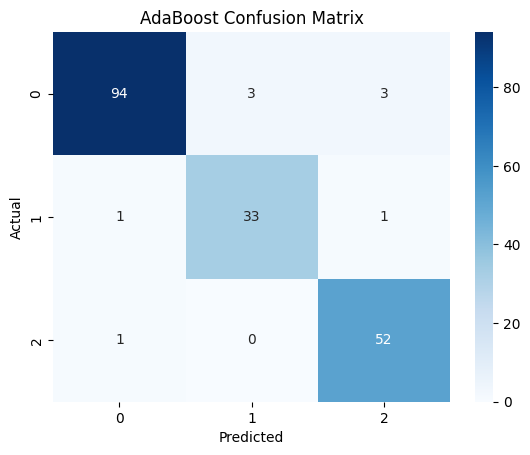

In [ ]:
# Confusion Matrix Heatmap
labels = np.unique(y_test)

cm = confusion_matrix(y_test, y_pred_ada, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("AdaBoost Confusion Matrix")
plt.show()

In [ ]:
# Macro average → treats all classes equally
precision_macro = precision_score(y_test, y_pred_ada, average='macro')
recall_macro = recall_score(y_test, y_pred_ada, average='macro')
f1_macro = f1_score(y_test, y_pred_ada, average='macro')

print("For AdaBoost Classifier: ")
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1:", f1_macro)

For AdaBoost Classifier: 
Macro Precision: 0.941468253968254
Macro Recall: 0.9546630727762803
Macro F1: 0.9476298595416975


Got an accuracy of 95.2% using AdaBoost

**5) DECISION TREE**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
# initialize the model
dt = DecisionTreeClassifier(random_state=42)

In [ ]:
dt.fit(x_train_res, y_train_res)

DecisionTreeClassifier(random_state=42)

In [ ]:
# HYPERPARAMETER TUNING
param_grid_dt = {
    'max_depth': [3,5,7,None],
    'min_samples_split': [2,5,10],
    'criterion': ['gini', 'entropy']
}

# None: no limit of tree depth... go till pure splitting is achieved
# 'criterion': controls how impurity is measured during splits

In [ ]:
grid_search_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='accuracy')
grid_search_dt.fit(x_train_res, y_train_res)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, None],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [ ]:
print("best parameters: ", grid_search_dt.best_params_)

best parameters:  {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 10}


In [ ]:
# cross validation accuracy
cv_scores_dt = cross_val_score(grid_search_dt.best_estimator_, x_train_res, y_train_res, cv=5)
print("cross validation accuracy score: ", cv_scores_dt)
print("mean CV accuracy: ", np.mean(cv_scores_dt))

cross validation accuracy score:  [0.97916667 0.95833333 0.98333333 0.9875     0.99166667]
mean CV accuracy:  0.9800000000000001


In [ ]:
# final evaluation on test dataset
best_model_dt = grid_search_dt.best_estimator_
y_pred_dt = best_model_dt.predict(x_test)

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
print("confusion_matrix: \n", cm_dt)

confusion_matrix: 
 [[95  3  2]
 [ 0 34  1]
 [ 1  0 52]]


In [ ]:
print("accuracy score: ", accuracy_score(y_test, y_pred_dt))

accuracy score:  0.9627659574468085


In [ ]:
print("classification_report: \n", classification_report(y_test, y_pred_dt))

classification_report: 
               precision    recall  f1-score   support

           0       0.99      0.95      0.97       100
           1       0.92      0.97      0.94        35
           2       0.95      0.98      0.96        53

    accuracy                           0.96       188
   macro avg       0.95      0.97      0.96       188
weighted avg       0.96      0.96      0.96       188



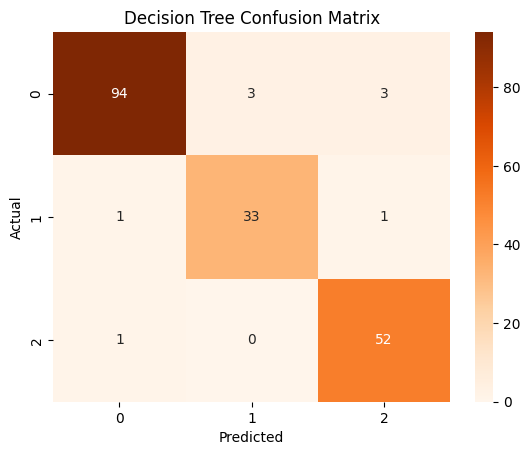

In [ ]:
# Confusion Matrix Heatmap
labels = np.unique(y_test)

cm_dt = confusion_matrix(y_test, y_pred_dt, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [ ]:
# Macro average → treats all classes equally
precision_macro = precision_score(y_test, y_pred_dt, average='macro')
recall_macro = recall_score(y_test, y_pred_dt, average='macro')
f1_macro = f1_score(y_test, y_pred_dt, average='macro')

print("For Decision Tree Classifier: ")
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1:", f1_macro)

For Decision Tree Classifier: 
Macro Precision: 0.9513189325689325
Macro Recall: 0.9675202156334232
Macro F1: 0.9589317208364827


Got an accuracy of 96.27% using Decision Tree